--

# 03 · Time Series + Cohort + Time Features — 时间序列、Cohort 与时间特征工程

## 1. 模块目标（Objective）

本模块从 **平台趋势（Trend）**、**用户生命周期（Cohort）** 与 **用户级时间特征（Time Features）** 三个层面挖掘时间维度信息，并将其转化为可建模特征，为后续预测建模与运营分析提供稳定的时序信号输入。

该模块的核心目标包括：

* 识别平台核心指标的趋势变化与周期性波动（DAU / Events / Buyers）
* 通过 Cohort 留存刻画用户生命周期衰减规律与复访水平
* 构建用户级时间窗口特征、趋势特征与行为节律特征
* 输出可复用的用户级时间特征表，用于后续预测与分群联动分析

---

## 2. 数据输入（Input Tables）

本模块使用的数据来自 `01_feature_engineering` 阶段输出的增强行为日志表：

* **events_enriched_all.parquet**
  行为日志（用户维度行为序列），包含 `view / addtocart / transaction` 等事件类型，及 `transactionid` 等成交标识字段。

**关键字段：**

* `visitorid`（用户ID）
* `dt`（事件发生时间，UTC）
* `event`（事件类型：view/addtocart/transaction）
* `transactionid`（成交标识，成交事件非空）

---

## 3. 关键设计决策（Key Design Choices）

### 3.1 成交事件口径（Transaction Definition）

由于数据未提供独立订单表，本模块将成交事件定义为满足任一条件：

* `event == 'transaction'`
* 或 `transactionid` 非空

并以此构建 **成交用户数（Buyers）**、成交事件数等指标。

---

### 3.2 平台趋势指标选择（Trend Metrics）

平台趋势分析选取可直接反映平台活跃与转化强度的核心指标：

* `DAU`：每日活跃用户（按日去重）
* `Events`：每日行为量（日志行数）
* `Buyers`：每日成交用户数（当日发生成交的用户去重数）

同时引入：

* `MA7 / MA14`：7/14 日滑动平均，用于平滑噪声并观察趋势
* `Day-of-Week Seasonality`：按星期几汇总平均 DAU，用于识别周周期性

---

### 3.3 Cohort 构建口径（Cohort Definition）

Cohort 按用户首次活跃日期（首次出现行为的日期）构建：

* `cohort_date = min(date)`
* `day_idx = date - cohort_date`（距首次活跃日的天数）

留存口径采用“严格日留存”：

* D7 留存：`day_idx == 7` 当天是否回访
  （而非 1~7 天内任意回访）

为提升可读性，额外提供 **周粒度 Cohort（Weekly Cohort）** 版本，减少行数并增强稳定性。

---

### 3.4 时间特征工程设计（Time Feature Engineering）

用户级时间特征主要覆盖四类信号：

1. **滚动窗口特征（Rolling Windows）**

* 近 7/14/30 天事件数、活跃天数、成交事件数

2. **行为趋势特征（Trend Features）**

* `recent7 vs prev7` 的增长率（Events / Transactions）

3. **行为节律特征（Rhythm Features）**

* 事件间隔（小时）的均值 / 方差 / 中位数（衡量行为频率稳定性）

4. **近端转化意图特征（Intent Features）**

* 近 3 天游览/加购、加购未成交标记等

---

## 4. 平台趋势分析（Trend Analysis）

本模块输出并保存以下图表（含 7/14 日滑动平均）：

* **DAU Trend**：每日活跃用户趋势
* **Event Volume Trend**：每日行为量趋势
* **Buyers Trend**：每日成交用户趋势
* **Weekly Seasonality**：按星期几的平均 DAU

> 观察到指标存在明显周周期波动（工作日与周末差异显著）。
> 时间末端存在断崖式下滑，推测为数据截断或最后日期不完整导致的边界效应。

---

## 5. Cohort 留存分析（Retention）

构建 0~30 天 Cohort 留存热力图，并输出关键留存指标。

在严格日留存口径下，整体留存水平如下（跨 Cohort 汇总）：

* **D1 留存：mean ≈ 2.72%（median ≈ 2.78%）**
* **D7 留存：mean ≈ 0.53%（median ≈ 0.53%）**
* **D14 留存：mean ≈ 0.29%（median ≈ 0.29%）**
* **D30 留存：mean ≈ 0.12%（median ≈ 0.13%）**

> 留存呈快速衰减，符合曝光型电商行为日志特征：大量用户为一次性浏览用户，复访占比较低。
> 使用 Weekly Cohort 聚合后留存结构更平滑，适合报告展示与横向对比。

---

## 6. 用户级时间特征表（User-level Time Features）

本模块最终输出用户级时间特征表，用于后续建模与运营分析。特征包括：

* `recency_days / lifetime_days / active_days`（生命周期与新鲜度）
* `events_7d/14d/30d`、`active_days_7d/14d/30d`（滚动窗口行为强度）
* `txn_events_7d/14d/30d`（近端成交强度）
* `events_growth_7v7 / txn_growth_7v7`（近期 vs 历史趋势）
* `gap_mean_hours / gap_std_hours / gap_p50_hours`（行为节律）
* `addtocart_3d / view_7d / intent_cart_no_txn_7d`（近端意图）

---

## 7. 模块输出（Outputs）

本模块最终产出以下结果：

* 平台趋势数据表：`platform_trend_daily.csv`
* 平台趋势图：`trend_DAU.png / trend_Events.png / trend_Buyers.png`
* 周周期图：`seasonality_DAU_dow.png`
* Cohort 留存汇总：`cohort_retention_summary.csv`
* Cohort 留存热力图：`cohort_retention_heatmap.png`（含 weekly 版本）
* 用户级时间特征表：`user_time_features.csv / parquet`

---

## 8. 后续分析方向（Next Steps）

基于本模块产出的趋势与时间特征，后续将进一步开展：

1. **时间序列预测（DAU / Buyers 别模型的时序解释力
4. **异常波动检测**：识别周期性以外的结构性变化并定位原因（活动/投放/数据缺口）

---

如果你确认“对，就是要这种格式”，我下一步可以把 **模块 01（特征工程）/ 模块 04（预测建模）/ 模块 05（策略与实验）**也都统一成同款风格（你给我模块标题+你想写的重点，我就按这个模板落地）。
归项

> 明日任务：先完成 baseline 与 1 个传统模型的对比（以 MAE/MAPE 评估），并输出预测可视化与误差分析。


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"E:\data_analysis\ecommece\data_clean\01_feature_engineering\events_enriched_all.parquet"
OUT_DIR = os.path.join(os.path.dirname(DATA_PATH), "..", "03_time_cohort_features")
OUT_DIR = os.path.abspath(OUT_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_parquet(DATA_PATH).copy()

df.rename(columns={
    "visitorid": "user_id",
    "dt": "event_time",
    "event": "event_name",
    "transactionid": "transaction_id"
}, inplace=True)

df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
df = df.dropna(subset=["user_id", "event_time"])
df["date"] = df["event_time"].dt.floor("D")

df["event_name"] = df["event_name"].astype(str).str.lower().str.strip()

df["is_txn"] = (df["event_name"].isin(["transaction", "purchase", "pay", "order"])) | (df["transaction_id"].notna())

SNAPSHOT_DATE = df["date"].max()
print("Snapshot date:", SNAPSHOT_DATE.date())
print("rows:", len(df), "| users:", df["user_id"].nunique())
print("event_name counts:", df["event_name"].value_counts().head(10).to_dict())
print("txn rows:", int(df["is_txn"].sum()))
print("OUT_DIR:", OUT_DIR)

Snapshot date: 2015-09-18
rows: 2755641 | users: 1407580
event_name counts: {'view': 2664218, 'addtocart': 68966, 'transaction': 22457}
txn rows: 22457
OUT_DIR: E:\data_analysis\ecommece\data_clean\03_time_cohort_features


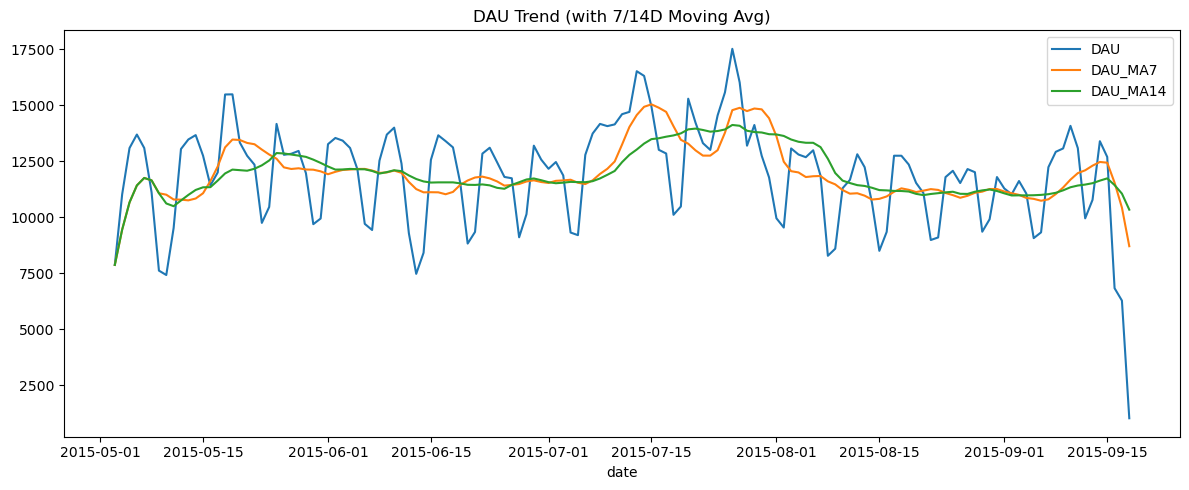

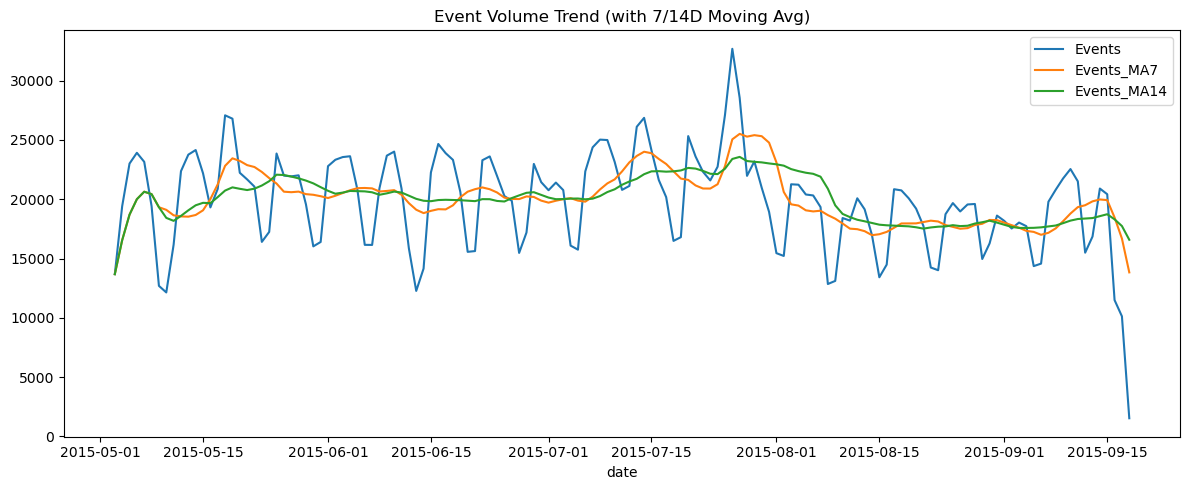

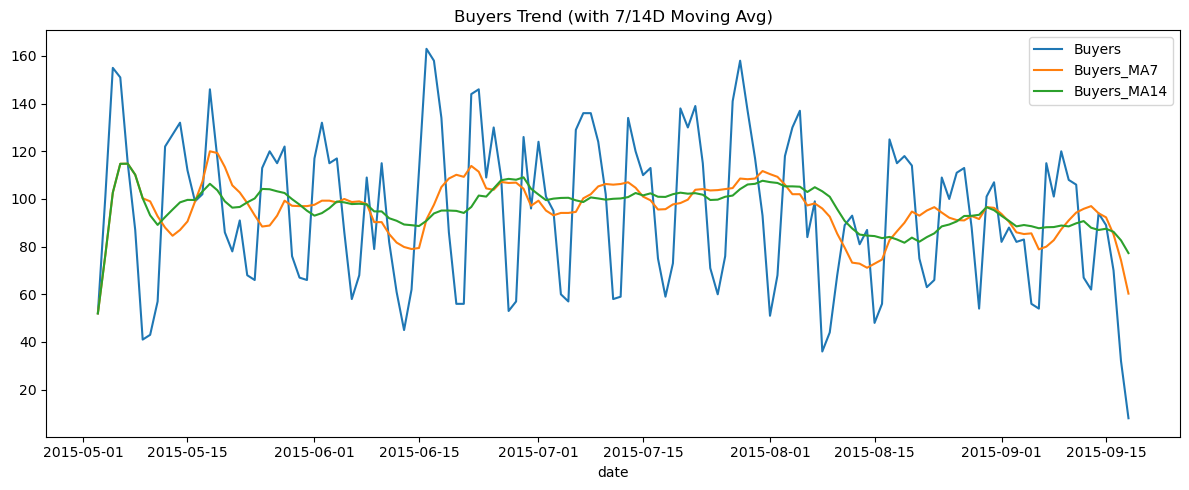

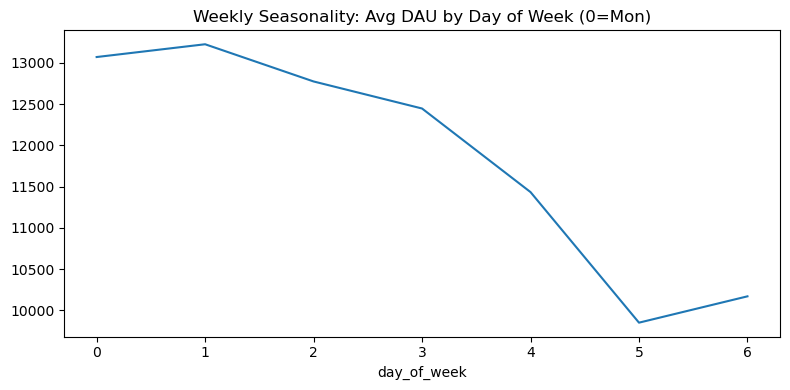

In [3]:
dau = df.groupby("date")["user_id"].nunique().rename("DAU").reset_index()
evt_cnt = df.groupby("date").size().rename("Events").reset_index()
buyers = df[df["is_txn"]].groupby("date")["user_id"].nunique().rename("Buyers").reset_index()

trend = dau.merge(evt_cnt, on="date", how="outer").merge(buyers, on="date", how="outer")
trend = trend.sort_values("date").fillna(0)

for w in [7, 14]:
    trend[f"DAU_MA{w}"] = trend["DAU"].rolling(w, min_periods=1).mean()
    trend[f"Events_MA{w}"] = trend["Events"].rolling(w, min_periods=1).mean()
    trend[f"Buyers_MA{w}"] = trend["Buyers"].rolling(w, min_periods=1).mean()

trend.to_csv(os.path.join(OUT_DIR, "platform_trend_daily.csv"), index=False, encoding="utf-8-sig")

def plot_series(df_, y_cols, title, outpath):
    plt.figure(figsize=(12, 5))
    for c in y_cols:
        plt.plot(df_["date"], df_[c], label=c)
    plt.title(title)
    plt.xlabel("date")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_series(trend, ["DAU", "DAU_MA7", "DAU_MA14"],
            "DAU Trend (with 7/14D Moving Avg)",
            os.path.join(OUT_DIR, "trend_DAU.png"))

plot_series(trend, ["Events", "Events_MA7", "Events_MA14"],
            "Event Volume Trend (with 7/14D Moving Avg)",
            os.path.join(OUT_DIR, "trend_Events.png"))

plot_series(trend, ["Buyers", "Buyers_MA7", "Buyers_MA14"],
            "Buyers Trend (with 7/14D Moving Avg)",
            os.path.join(OUT_DIR, "trend_Buyers.png"))

trend["dow"] = pd.to_datetime(trend["date"]).dt.dayofweek  # 0=Mon
dow = trend.groupby("dow")["DAU"].mean().reset_index()
plt.figure(figsize=(8, 4))
plt.plot(dow["dow"], dow["DAU"])
plt.title("Weekly Seasonality: Avg DAU by Day of Week (0=Mon)")
plt.xlabel("day_of_week")
plt.tight_layout()
plt.show()

In [4]:
# ===== Cohort：按首次活跃 date + 留存热力图 =====
RETENTION_DAYS = [7, 14, 30]
HEATMAP_DAYS = 30
WINDOWS = [7, 14, 30]

first_active = df.groupby("user_id")["date"].min().rename("cohort_date").reset_index()
user_day = df[["user_id", "date"]].drop_duplicates()

cohort_df = user_day.merge(first_active, on="user_id", how="left")
cohort_df["day_idx"] = (cohort_df["date"] - cohort_df["cohort_date"]).dt.days
cohort_df = cohort_df[cohort_df["day_idx"] >= 0]

cohort_size = cohort_df.groupby("cohort_date")["user_id"].nunique().rename("cohort_size")

# 7/14/30 天留存（严格：那一天是否回来）
ret_parts = [cohort_size]
for d in RETENTION_DAYS:
    active_d = cohort_df[cohort_df["day_idx"] == d].groupby("cohort_date")["user_id"].nunique()
    ret_parts.append((active_d / cohort_size).rename(f"retention_d{d}"))

retention = pd.concat(ret_parts, axis=1).reset_index().sort_values("cohort_date")
retention.to_csv(os.path.join(OUT_DIR, "cohort_retention_summary.csv"), index=False, encoding="utf-8-sig")

# 热力图（0~30天）
heat = cohort_df[cohort_df["day_idx"].between(0, HEATMAP_DAYS)] \
    .groupby(["cohort_date", "day_idx"])["user_id"].nunique().unstack(fill_value=0)
heat = heat.div(cohort_size, axis=0)

plt.figure(figsize=(14, max(4, len(heat) * 0.25)))
plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="Retention Rate")
plt.yticks(range(len(heat.index)), [d.strftime("%Y-%m-%d") for d in heat.index])
plt.xticks(range(0, heat.shape[1], 2), list(heat.columns[::2]))
plt.title(f"Cohort Retention Heatmap (0-{HEATMAP_DAYS} days)")
plt.xlabel("days since first active")
plt.ylabel("cohort_date")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cohort_retention_heatmap.png"), dpi=180)
plt.close()

# ===== 用户级时间特征：滚动窗口 + 趋势 + 节律 + 近端意图 =====
u_agg = df.groupby("user_id").agg(
    first_date=("date", "min"),
    last_date=("date", "max"),
    total_events=("event_name", "size"),
    active_days=("date", "nunique"),
    txn_cnt=("is_txn", "sum"),
).reset_index()

u_agg["lifetime_days"] = (u_agg["last_date"] - u_agg["first_date"]).dt.days + 1
u_agg["recency_days"] = (SNAPSHOT_DATE - u_agg["last_date"]).dt.days

# 用户-日事件数 / 成交事件数
ud = df.groupby(["user_id", "date"]).agg(
    events_cnt=("event_name", "size"),
    txn_events=("is_txn", "sum")
).reset_index()

def window_feats(ud_df, days):
    start = SNAPSHOT_DATE - pd.Timedelta(days=days - 1)
    sub = ud_df[ud_df["date"].between(start, SNAPSHOT_DATE)]
    return sub.groupby("user_id").agg(
        **{
            f"events_{days}d": ("events_cnt", "sum"),
            f"active_days_{days}d": ("date", "nunique"),
            f"txn_events_{days}d": ("txn_events", "sum"),
        }
    ).reset_index()

u_feat = u_agg.copy()
for w in WINDOWS:
    u_feat = u_feat.merge(window_feats(ud, w), on="user_id", how="left")

for w in WINDOWS:
    for c in [f"events_{w}d", f"active_days_{w}d", f"txn_events_{w}d"]:
        u_feat[c] = u_feat[c].fillna(0)

# 趋势：最近7天 vs 前7天（事件增长率 + 成交增长率）
recent_start = SNAPSHOT_DATE - pd.Timedelta(days=6)
prev_start = SNAPSHOT_DATE - pd.Timedelta(days=13)
prev_end   = SNAPSHOT_DATE - pd.Timedelta(days=7)

recent = ud[ud["date"].between(recent_start, SNAPSHOT_DATE)].groupby("user_id")[["events_cnt","txn_events"]].sum()
prev   = ud[ud["date"].between(prev_start, prev_end)].groupby("user_id")[["events_cnt","txn_events"]].sum()

recent = recent.rename(columns={"events_cnt":"events_recent7","txn_events":"txn_recent7"}).reset_index()
prev   = prev.rename(columns={"events_cnt":"events_prev7","txn_events":"txn_prev7"}).reset_index()

u_feat = u_feat.merge(recent, on="user_id", how="left").merge(prev, on="user_id", how="left")
for c in ["events_recent7","txn_recent7","events_prev7","txn_prev7"]:
    u_feat[c] = u_feat[c].fillna(0)

u_feat["events_growth_7v7"] = (u_feat["events_recent7"] - u_feat["events_prev7"]) / (u_feat["events_prev7"] + 1e-6)
u_feat["txn_growth_7v7"]    = (u_feat["txn_recent7"] - u_feat["txn_prev7"]) / (u_feat["txn_prev7"] + 1e-6)

# 节律：事件间隔（小时）
tmp = df[["user_id", "event_time"]].sort_values(["user_id", "event_time"])
tmp["prev_time"] = tmp.groupby("user_id")["event_time"].shift(1)
tmp["gap_hours"] = (tmp["event_time"] - tmp["prev_time"]).dt.total_seconds() / 3600.0

gap_feat = tmp.groupby("user_id")["gap_hours"].agg(
    gap_mean_hours="mean",
    gap_std_hours="std",
    gap_p50_hours=lambda x: np.nanmedian(x),
).reset_index()

u_feat = u_feat.merge(gap_feat, on="user_id", how="left")

# 近端意图：近3天加购、近7天浏览
def count_recent(name, days):
    start = SNAPSHOT_DATE - pd.Timedelta(days=days - 1)
    sub = df[df["date"].between(start, SNAPSHOT_DATE) & (df["event_name"] == name)]
    return sub.groupby("user_id").size()

# 兼容这份数据典型事件名：view / addtocart / transaction
u_feat = u_feat.merge(count_recent("addtocart", 3).rename("addtocart_3d"), on="user_id", how="left")
u_feat = u_feat.merge(count_recent("view", 7).rename("view_7d"), on="user_id", how="left")
u_feat["addtocart_3d"] = u_feat["addtocart_3d"].fillna(0)
u_feat["view_7d"] = u_feat["view_7d"].fillna(0)

# 近端“加购未成交”
u_feat["intent_cart_no_txn_7d"] = ((u_feat["addtocart_3d"] > 0) & (u_feat["txn_events_7d"] == 0)).astype(int)

# 导出用户级时间特征表
u_feat["snapshot_date"] = SNAPSHOT_DATE
u_feat = u_feat.sort_values("user_id")

u_feat.to_csv(os.path.join(OUT_DIR, "user_time_features.csv"), index=False, encoding="utf-8-sig")
try:
    u_feat.to_parquet(os.path.join(OUT_DIR, "user_time_features.parquet"), index=False)
except Exception as e:
    print("Parquet export skipped:", e)

print("Done:", OUT_DIR)
print("Generated:",
      "\n - platform_trend_daily.csv + trend_*.png + seasonality_DAU_dow.png",
      "\n - cohort_retention_summary.csv + cohort_retention_heatmap.png",
      "\n - user_time_features.csv / .parquet")


C:\Users\llj68\AppData\Local\Temp\ipykernel_24328\1285116716.py:104: RuntimeWarning: All-NaN slice encountered
  gap_p50_hours=lambda x: np.nanmedian(x),


Done: E:\data_analysis\ecommece\data_clean\03_time_cohort_features
Generated: 
 - platform_trend_daily.csv + trend_*.png + seasonality_DAU_dow.png 
 - cohort_retention_summary.csv + cohort_retention_heatmap.png 
 - user_time_features.csv / .parquet


In [5]:
# heat: cohort_date x day_idx 的留存率矩阵（你上面已经算出来了）
# cohort_size: 每个 cohort 的人数（你上面也有）

check_days = [1, 7, 14, 30]
for d in check_days:
    if d in heat.columns:
        s = heat[d].dropna()
        print(
            f"D{d}: mean={s.mean():.4f}, median={s.median():.4f}, "
            f"p90={s.quantile(0.9):.4f}, max={s.max():.4f}, cohorts={len(s)}"
        )
    else:
        print(f"D{d}: not in heat columns")


D1: mean=0.0272, median=0.0278, p90=0.0325, max=0.0515, cohorts=139
D7: mean=0.0053, median=0.0053, p90=0.0074, max=0.0173, cohorts=139
D14: mean=0.0029, median=0.0029, p90=0.0042, max=0.0133, cohorts=139
D30: mean=0.0012, median=0.0013, p90=0.0022, max=0.0075, cohorts=139


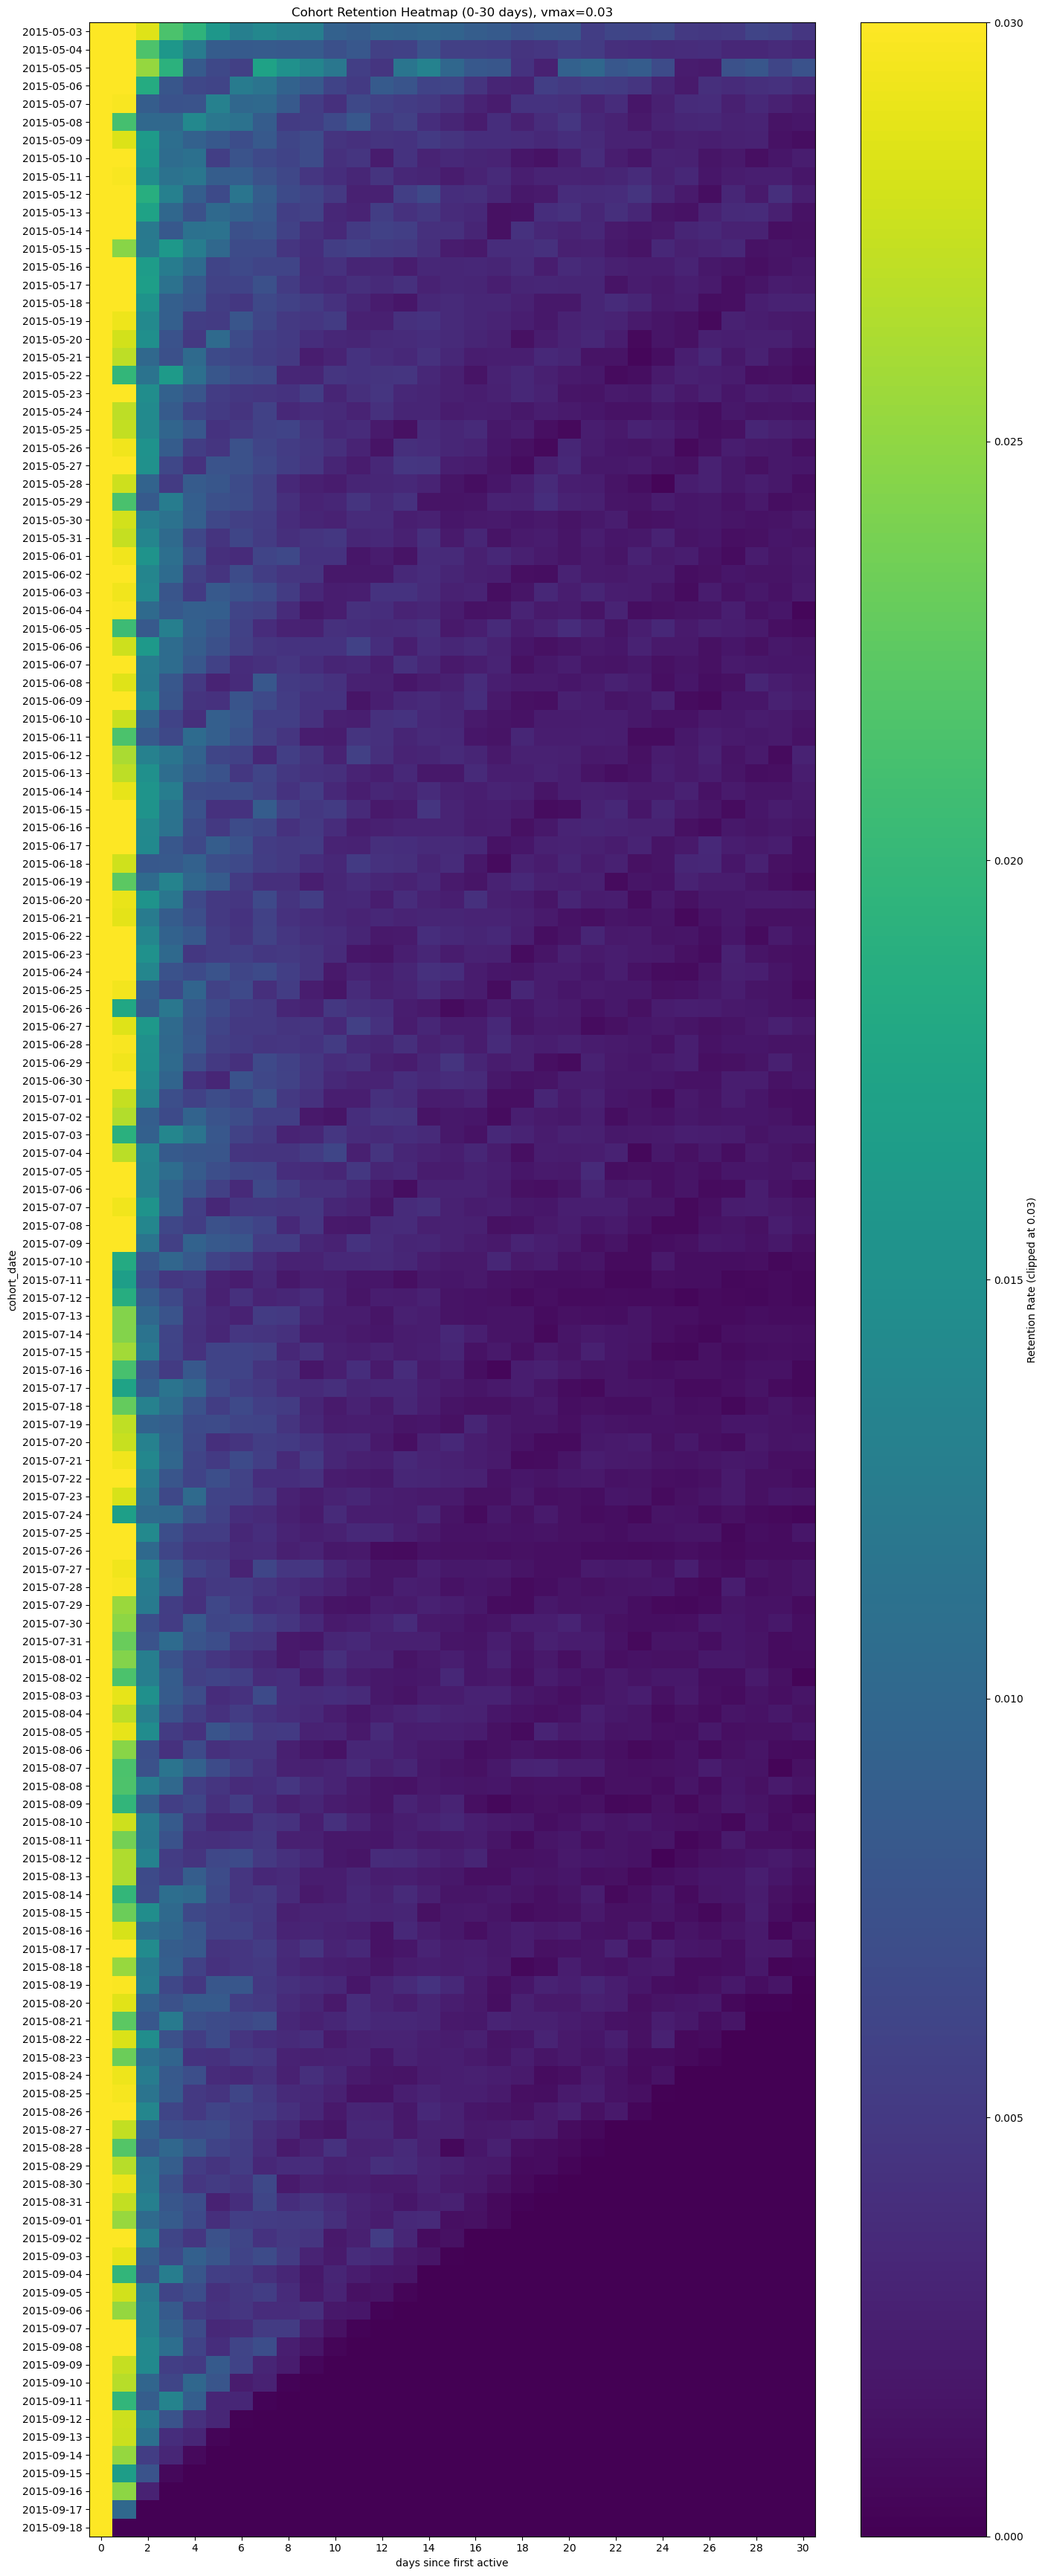

In [10]:
vmax = 0.03   # 你可以试 0.05 / 0.10 / 0.20
plt.figure(figsize=(14, max(4, len(heat) * 0.25)))
plt.imshow(heat.values, aspect="auto", vmin=0, vmax=vmax)
plt.colorbar(label=f"Retention Rate (clipped at {vmax})")
plt.yticks(range(len(heat.index)), [d.strftime("%Y-%m-%d") for d in heat.index])
plt.xticks(range(0, heat.shape[1], 2), list(heat.columns[::2]))
plt.title(f"Cohort Retention Heatmap (0-{HEATMAP_DAYS} days), vmax={vmax}")
plt.xlabel("days since first active")
plt.ylabel("cohort_date")
plt.tight_layout()
plt.show()

C:\Users\llj68\AppData\Local\Temp\ipykernel_24328\1581985969.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort_df_w["cohort_week"] = cohort_df_w["cohort_date"].dt.to_period("W").dt.start_time


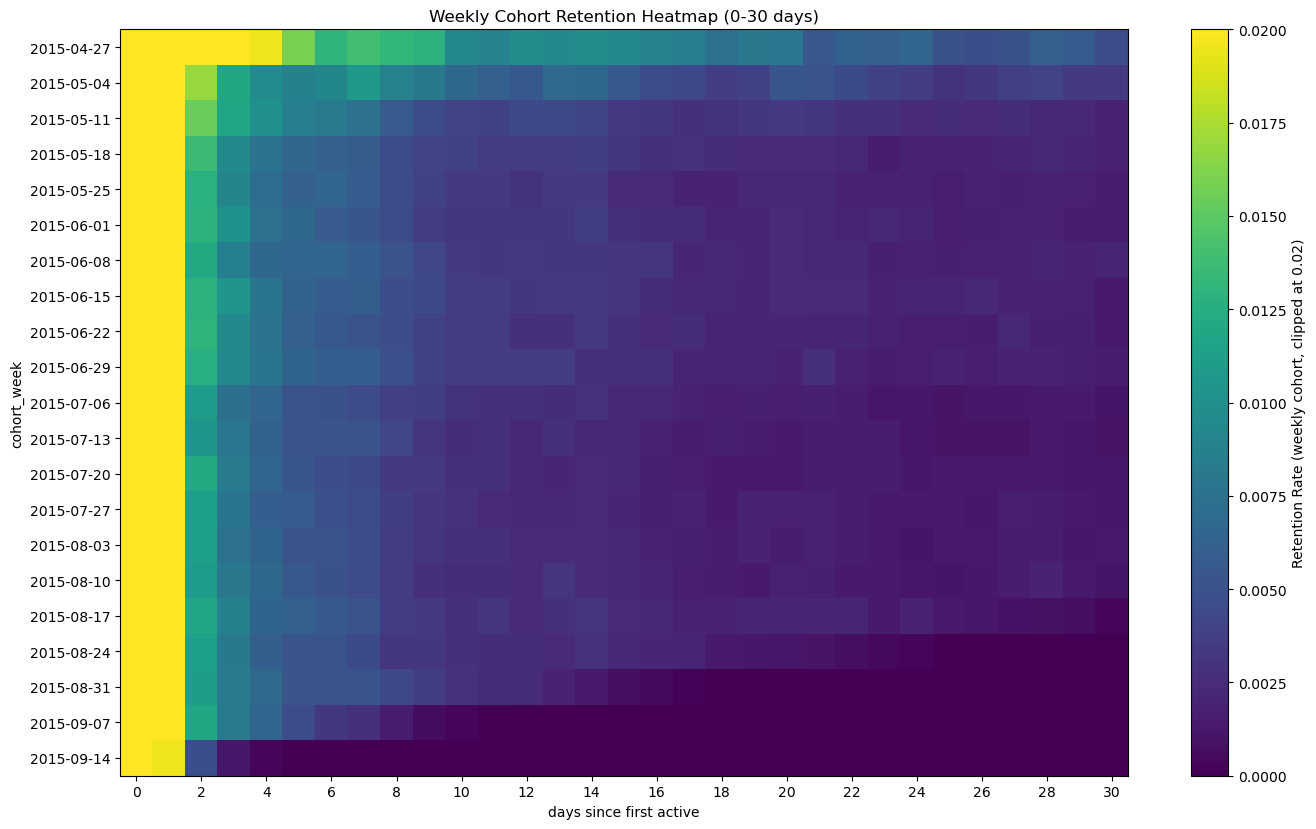

In [7]:
# 1) 周 cohort
cohort_df_w = cohort_df.copy()
cohort_df_w["cohort_week"] = cohort_df_w["cohort_date"].dt.to_period("W").dt.start_time

# 2) 周 cohort_size
cohort_size_w = cohort_df_w.groupby("cohort_week")["user_id"].nunique()

# 3) 周热力矩阵（0~30天）
heat_w = cohort_df_w[cohort_df_w["day_idx"].between(0, HEATMAP_DAYS)] \
    .groupby(["cohort_week", "day_idx"])["user_id"].nunique().unstack(fill_value=0)

heat_w = heat_w.div(cohort_size_w, axis=0)

# 4) 画图（同样建议 clip vmax）
vmax = 0.02
plt.figure(figsize=(14, max(4, len(heat_w) * 0.4)))
plt.imshow(heat_w.values, aspect="auto", vmin=0, vmax=vmax)
plt.colorbar(label=f"Retention Rate (weekly cohort, clipped at {vmax})")
plt.yticks(range(len(heat_w.index)), [d.strftime("%Y-%m-%d") for d in heat_w.index])
plt.xticks(range(0, heat_w.shape[1], 2), list(heat_w.columns[::2]))
plt.title(f"Weekly Cohort Retention Heatmap (0-{HEATMAP_DAYS} days)")
plt.xlabel("days since first active")
plt.ylabel("cohort_week")
plt.tight_layout()
plt.show()

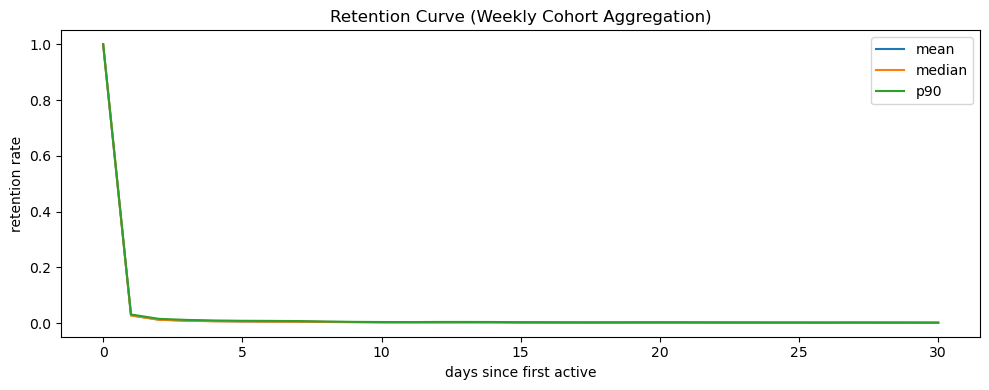

In [8]:
# heat_w: 你已经算出来的 retention 矩阵（周 cohort 那个更推荐）
M = heat_w.copy()

curve = pd.DataFrame({
    "day": M.columns.astype(int),
    "mean": M.mean(axis=0).values,
    "median": M.median(axis=0).values,
    "p90": M.quantile(0.9, axis=0).values,
}).sort_values("day")

plt.figure(figsize=(10,4))
plt.plot(curve["day"], curve["mean"], label="mean")
plt.plot(curve["day"], curve["median"], label="median")
plt.plot(curve["day"], curve["p90"], label="p90")
plt.title("Retention Curve (Weekly Cohort Aggregation)")
plt.xlabel("days since first active")
plt.ylabel("retention rate")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "retention_curve_weekly.png"), dpi=180)
plt.show()

In [9]:
tmp = df.copy()
tmp["hour"] = tmp["event_time"].dt.hour

last7 = tmp[tmp["date"] >= (SNAPSHOT_DATE - pd.Timedelta(days=6))]
coverage = last7.groupby("date").agg(
    rows=("user_id", "size"),
    min_hour=("hour", "min"),
    max_hour=("hour", "max")
).reset_index()
coverage

,date,rows,min_hour,max_hour
0,2015-09-12 00:00:00+00:00,15495,0,23
1,2015-09-13 00:00:00+00:00,16856,0,23
2,2015-09-14 00:00:00+00:00,20905,0,23
3,2015-09-15 00:00:00+00:00,20425,0,23
4,2015-09-16 00:00:00+00:00,11494,0,23
5,2015-09-17 00:00:00+00:00,10126,0,23
6,2015-09-18 00:00:00+00:00,1528,0,2


# Time Series Forecasting — 平台活跃预测

## 1. Problem Definition
- 预测对象：DAU（日活用户数）
- 预测频率：Daily
- 预测窗口：未来 14 / 30 天

## 2. Data Preparation
- 聚合为日序列
- 处理末尾截断（drop last N days）
- 可视化原始序列 + MA

## 3. Baseline Models
- Naive Forecast
- Seasonal Naive (lag=7)
- Evaluation (MAE / MAPE)

## 4. SARIMA Model
- 参数选择思路
- 模型训练
- 预测结果 & 误差

## 5. Prophet Model
- Trend + Weekly Seasonality
- Forecast visualization
- 与 SARIMA 对比

## 6. Model Comparison
- 指标对比表
- 哪个模型在什么场景更好

## 7. Conclusion
- 可预测性总结
- 业务应用场景


In [82]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"E:\data_analysis\ecommece\data_clean\01_feature_engineering\events_enriched_all.parquet"
OUT_DIR   = r"E:\data_analysis\ecommece\data_clean\03_time_cohort_features\time_series"
os.makedirs(OUT_DIR, exist_ok=True)

print("OUT_DIR:", OUT_DIR)

OUT_DIR: E:\data_analysis\ecommece\data_clean\03_time_cohort_features\time_series


In [83]:
df = pd.read_parquet(DATA_PATH)
df.head()

,visitorid,itemid,event,timestamp,dt,transactionid,available,categoryid
0,257597,355908,view,1433221332117,2015-06-02 05:02:12.117000+00:00,<NA>,1,1173
1,992329,248676,view,1433224214164,2015-06-02 05:50:14.164000+00:00,<NA>,1,1231
2,111016,318965,view,1433221999827,2015-06-02 05:13:19.827000+00:00,<NA>,-1,-1
3,483717,253185,view,1433221955914,2015-06-02 05:12:35.914000+00:00,<NA>,0,914
4,951259,367447,view,1433221337106,2015-06-02 05:02:17.106000+00:00,<NA>,0,491


In [84]:
df["dt"] = pd.to_datetime(df["dt"], errors = "coerce", utc = True)

df["date"] = df["dt"].dt.floor("D")
df = df.dropna(subset = ["date", "visitorid", "event"])

print("date range:", df["date"].min(), "->", df["date"].max())
df[["visitorid", "event", "dt", "date", "transactionid"]].head()

date range: 2015-05-03 00:00:00+00:00 -> 2015-09-18 00:00:00+00:00


,visitorid,event,dt,date,transactionid
0,257597,view,2015-06-02 05:02:12.117000+00:00,2015-06-02 00:00:00+00:00,<NA>
1,992329,view,2015-06-02 05:50:14.164000+00:00,2015-06-02 00:00:00+00:00,<NA>
2,111016,view,2015-06-02 05:13:19.827000+00:00,2015-06-02 00:00:00+00:00,<NA>
3,483717,view,2015-06-02 05:12:35.914000+00:00,2015-06-02 00:00:00+00:00,<NA>
4,951259,view,2015-06-02 05:02:17.106000+00:00,2015-06-02 00:00:00+00:00,<NA>


In [85]:
df["is_txn"] = df["transactionid"].notna() | (df["event"].astype(str).str.lower() == "transaction")

dau = df.groupby("date")["visitorid"].nunique().rename("DAU")
evt = df.groupby("date").size().rename("Events")
buyers = df[df["is_txn"]].groupby("date")["visitorid"].nunique().rename("Buyers")

daily = pd.concat([dau, evt, buyers], axis = 1).fillna(0).reset_index()
daily = daily.sort_values("date")

daily.to_csv(os.path.join(OUT_DIR, "daily_metrics.csv"), index=False, encoding="utf-8-sig")
daily.head(), daily.tail()

(                       date    DAU  Events  Buyers
 0 2015-05-03 00:00:00+00:00   7865   13682      52
 1 2015-05-04 00:00:00+00:00  11019   19413     101
 2 2015-05-05 00:00:00+00:00  13084   23011     155
 3 2015-05-06 00:00:00+00:00  13687   23920     151
 4 2015-05-07 00:00:00+00:00  13086   23157     115,
                          date    DAU  Events  Buyers
 134 2015-09-14 00:00:00+00:00  13389   20905      94
 135 2015-09-15 00:00:00+00:00  12687   20425      89
 136 2015-09-16 00:00:00+00:00   6824   11494      70
 137 2015-09-17 00:00:00+00:00   6270   10126      32
 138 2015-09-18 00:00:00+00:00   1016    1528       8)

In [86]:
tail = daily.tail(10).copy()
print(tail)

med7 = daily["Events"].tail(8).head(7).median()  # 最近7天（不含最后一天）
last_events = daily["Events"].iloc[-1]
print("median(last7 Events):", med7, " last day Events:", last_events)

                         date    DAU  Events  Buyers
129 2015-09-09 00:00:00+00:00  13066   21759     120
130 2015-09-10 00:00:00+00:00  14075   22548     108
131 2015-09-11 00:00:00+00:00  13080   21513     106
132 2015-09-12 00:00:00+00:00   9944   15495      67
133 2015-09-13 00:00:00+00:00  10768   16856      62
134 2015-09-14 00:00:00+00:00  13389   20905      94
135 2015-09-15 00:00:00+00:00  12687   20425      89
136 2015-09-16 00:00:00+00:00   6824   11494      70
137 2015-09-17 00:00:00+00:00   6270   10126      32
138 2015-09-18 00:00:00+00:00   1016    1528       8
median(last7 Events): 16856.0  last day Events: 1528


In [87]:
if last_events < 0.5 * med7:
    print("Drop last day due to truncation:", daily["date"].iloc[-1].date())
    daily = daily.iloc[:-1].copy()

print("new range:", daily["date"].min().date(), "->", daily["date"].max().date())

Drop last day due to truncation: 2015-09-18
new range: 2015-05-03 -> 2015-09-17


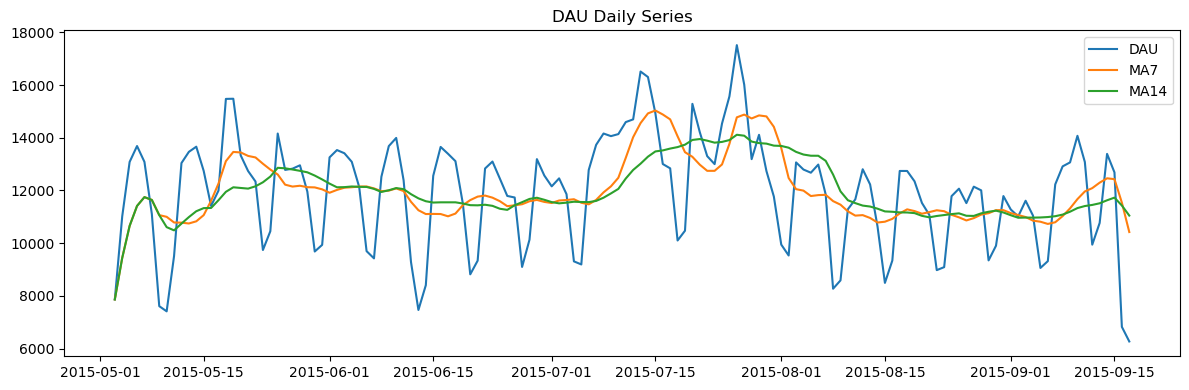

n_days: 138


In [88]:
y = daily.set_index("date")["DAU"].asfreq("D")
y = y.fillna(0)

y_ma7 = y.rolling(7, min_periods = 1).mean()
y_ma14 = y.rolling(14, min_periods = 1).mean()

plt.figure(figsize=(12,4))
plt.plot(y.index, y.values, label="DAU")
plt.plot(y_ma7.index, y_ma7.values, label="MA7")
plt.plot(y_ma14.index, y_ma14.values, label="MA14")
plt.title("DAU Daily Series")
plt.legend()
plt.tight_layout()
plt.show()

print("n_days:", len(y))

In [89]:
H = 30
train = y.iloc[:-H]
test = y.iloc[-H:]

print("train:", train.index.min().date(), "->", train.index.max().date(), "n=", len(train))
print("test :", test.index.min().date(),  "->", test.index.max().date(),  "n=", len(test))

train: 2015-05-03 -> 2015-08-18 n= 108
test : 2015-08-19 -> 2015-09-17 n= 30


In [90]:
def MAE(y_true, y_pred):
    return round(float(np.mean(np.abs(y_true.values -  y_pred.values))))

def MAPE(y_true, y_pred, eps = 1e-9):
    denom = np.maximum(np.abs(y_true.values), eps)
    return float(np.mean(np.abs((y_true.values - y_pred.values) / denom)))

pred_naive = pd.Series(train.iloc[-1], index=test.index)

mae_naive = MAE(test, pred_naive)
mape_naive = MAPE(test, pred_naive)

print("Naive MAE :", mae_naive)
print("Naive MAPE:", mape_naive)

Naive MAE : 1857
Naive MAPE: 0.20401436151543448


In [91]:
season = 7

last_season = train.iloc[-season:].values

rep = int(np.ceil(len(test) / season))
pred_snaive = np.tile(last_season, rep)[:len(test)]

pred_snaive = pd.Series(pred_snaive, index=test.index)

mae_snaive = MAE(test, pred_snaive)
mape_snaive = MAPE(test, pred_snaive)

print("SeasonalNaive(lag=7) MAE :", mae_snaive)
print("SeasonalNaive(lag=7) MAPE:", mape_snaive)

SeasonalNaive(lag=7) MAE : 1156
SeasonalNaive(lag=7) MAPE: 0.12718161722628868


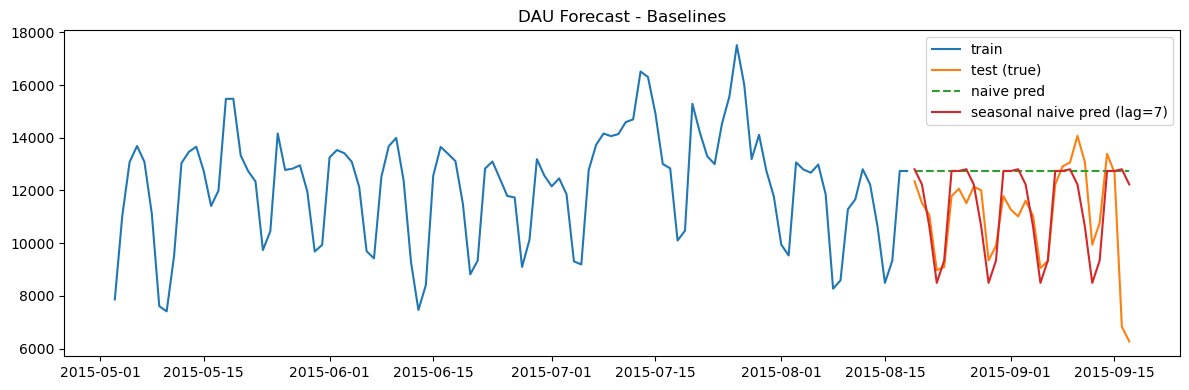

In [92]:
plt.figure(figsize=(12,4))
plt.plot(train.index, train.values, label="train")
plt.plot(test.index, test.values, label="test (true)")
plt.plot(test.index, pred_naive.values, "--", label="naive pred")
plt.plot(test.index, pred_snaive.values, label="seasonal naive pred (lag=7)")
plt.title("DAU Forecast - Baselines")
plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, "baseline_forecast.png"), dpi=180)
plt.show()


In [93]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

SEASON = 7 

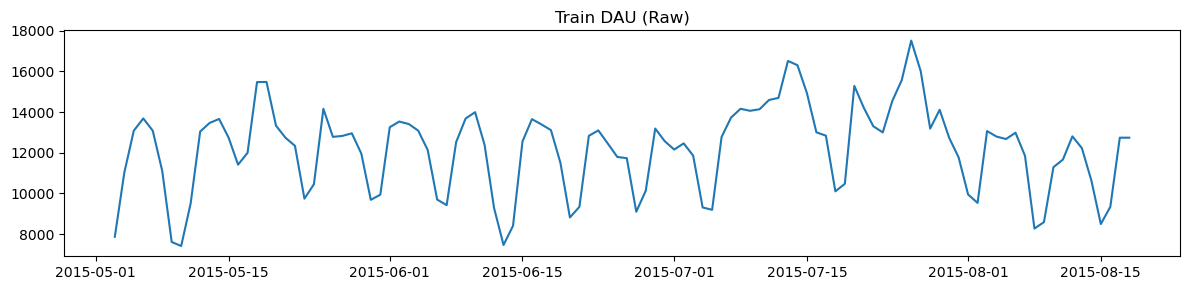

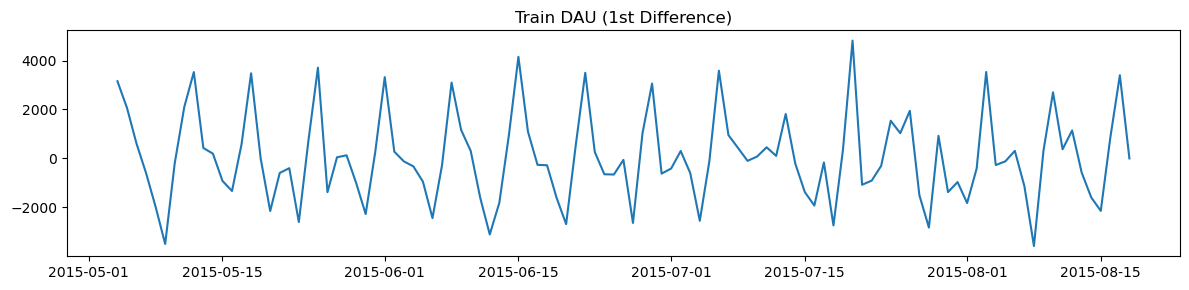

In [94]:
plt.figure(figsize=(12,3))
plt.plot(train.index, train.values)
plt.title("Train DAU (Raw)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(train.diff().dropna().index, train.diff().dropna().values)
plt.title("Train DAU (1st Difference)")
plt.tight_layout()
plt.show()

In [95]:
import itertools

def fit_sarima(y_train, order, sorder):
    model = SARIMAX(
        y_train,
        order = order,
        seasonal_order = sorder,
        enforce_stationarity = False,
        enforce_invertibility = False
    )
    res = model.fit(disp = False)
    return res

candidates = []
p_list = [0, 1, 2]
q_list = [0, 1, 2]
P_list = [0, 1]
Q_list = [0, 1]

d = 1
D = 1
s =SEASON

for p, q, P, Q in itertools.product(p_list, q_list, P_list, Q_list):
    order =(p, d, q)
    sorder = (P, D, Q, s)
    try:
        res = fit_sarima(train, order, sorder)
        candidates.append({
            "order": order,
            "seasonal_order": sorder,
            "aic": res.aic
        })
    except Exception as e:
        continue

cand_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
cand_df.head(10)

,order,seasonal_order,aic
0,"(1, 1, 2)","(0, 1, 1, 7)",1514.596928
1,"(2, 1, 2)","(0, 1, 1, 7)",1516.067300
2,"(1, 1, 2)","(1, 1, 1, 7)",1516.327670
3,"(0, 1, 2)","(0, 1, 1, 7)",1517.129633
4,"(2, 1, 2)","(1, 1, 1, 7)",1517.785319
5,"(0, 1, 2)","(1, 1, 1, 7)",1519.099509
6,"(1, 1, 1)","(0, 1, 1, 7)",1537.306084
7,"(2, 1, 1)","(0, 1, 1, 7)",1538.530134
8,"(1, 1, 1)","(1, 1, 1, 7)",1538.968864
9,"(2, 1, 1)","(1, 1, 1, 7)",1540.281382


In [96]:
topk = 3
top_models = cand_df.head(topk).to_dict("records")
top_models

[{'order': (1, 1, 2),
  'seasonal_order': (0, 1, 1, 7),
  'aic': 1514.5969275197965},
 {'order': (2, 1, 2),
  'seasonal_order': (0, 1, 1, 7),
  'aic': 1516.0672996410337},
 {'order': (1, 1, 2),
  'seasonal_order': (1, 1, 1, 7),
  'aic': 1516.3276702518808}]

In [97]:
sarima_reports = []

for m in top_models:
    order = m["order"]
    sorder = m["seasonal_order"]
    res = fit_sarima(train, order, sorder)

    fc = res.get_forecast(steps = len(test))
    pred = pd.Series(fc.predicted_mean.values, index = test.index)

    mae = MAE(test, pred)
    mape = MAPE(test, pred)

    sarima_reports.append(
        {
            "order": order,
            "seasonal_order": sorder,
            "AIC": res.aic,
            "MAE": mae,
            "MAPE": mape
        }
    )

sarima_report_df = pd.DataFrame(sarima_reports).sort_values("MAE").reset_index(drop=True)
sarima_report_df

,order,seasonal_order,AIC,MAE,MAPE
0,"(1, 1, 2)","(1, 1, 1, 7)",1516.327670,990,0.108559
1,"(1, 1, 2)","(0, 1, 1, 7)",1514.596928,1001,0.108263
2,"(2, 1, 2)","(0, 1, 1, 7)",1516.067300,1013,0.111683


BEST SARIMA: (1, 1, 2) (1, 1, 1, 7)  MAE: 990  MAPE: 0.10855862294937216


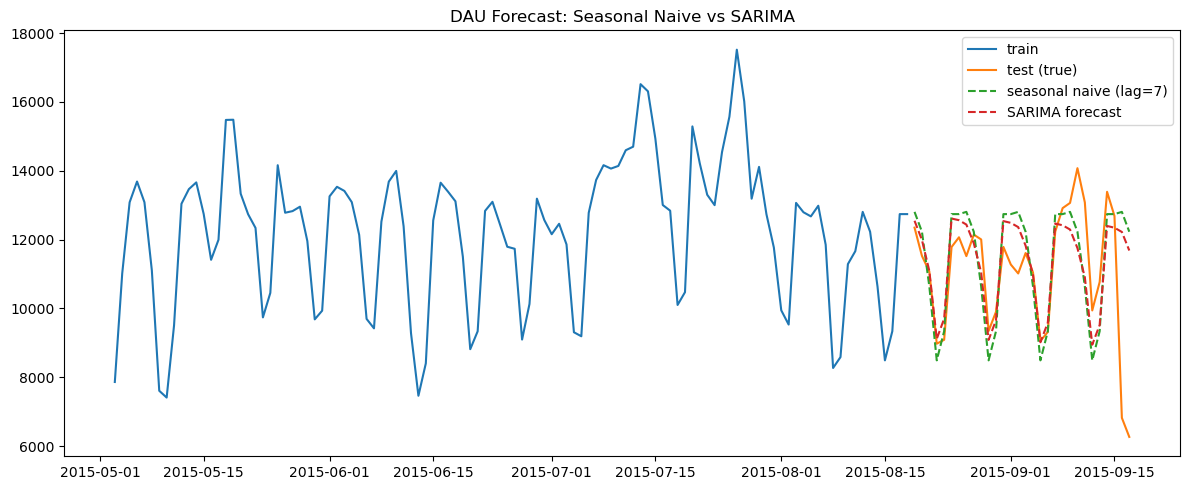

In [98]:
best = sarima_report_df.iloc[0]
best_order = tuple(best["order"])
best_sorder = tuple(best["seasonal_order"])

print("BEST SARIMA:", best_order, best_sorder, " MAE:", best["MAE"], " MAPE:", best["MAPE"])

best_res = fit_sarima(train, best_order, best_sorder)
fc = best_res.get_forecast(steps=len(test))
pred_sarima = pd.Series(fc.predicted_mean.values, index=test.index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train.values, label="train")
plt.plot(test.index, test.values, label="test (true)")
plt.plot(test.index, pred_snaive.values, "--", label="seasonal naive (lag=7)")
plt.plot(test.index, pred_sarima.values, "--", label="SARIMA forecast")
plt.title("DAU Forecast: Seasonal Naive vs SARIMA")
plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(OUT_DIR, "sarima_vs_snaive.png"), dpi=180)
plt.show()

In [99]:
from prophet import Prophet

In [100]:
train_idx = train.index.tz_localize(None)
test_idx  = test.index.tz_localize(None)

train_df = pd.DataFrame({"ds": train_idx, "y": train.values})
test_df  = pd.DataFrame({"ds": test_idx,  "y": test.values})

train_df.head(), test_df.head()

(          ds      y
 0 2015-05-03   7865
 1 2015-05-04  11019
 2 2015-05-05  13084
 3 2015-05-06  13687
 4 2015-05-07  13086,
           ds      y
 0 2015-08-19  12348
 1 2015-08-20  11527
 2 2015-08-21  11071
 3 2015-08-22   8977
 4 2015-08-23   9091)

In [101]:
m = Prophet(
    growth="linear",
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10.0
)

m.fit(train_df)

12:28:41 - cmdstanpy - INFO - Chain [1] start processing
12:28:42 - cmdstanpy - INFO - Chain [1] done processing


In [102]:
future = pd.DataFrame({"ds": test_df["ds"]})
forecast = m.predict(future)

pred_prophet = pd.Series(forecast["yhat"].values, index = test.index)

mae_prophet = MAE(test, pred_prophet)
mape_prophet = MAPE(test, pred_prophet)

print("Prophet MAE :", mae_prophet)
print("Prophet MAPE:", mape_prophet)

Prophet MAE : 1281
Prophet MAPE: 0.12751496951363664


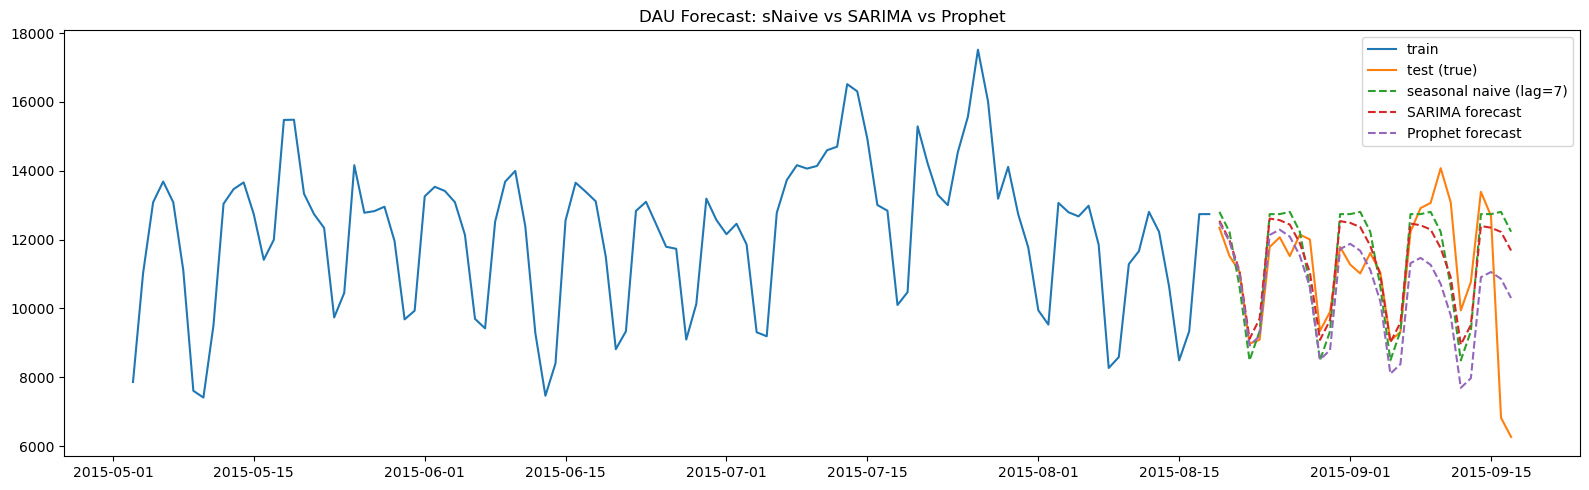

In [103]:
plt.figure(figsize=(16,5))
plt.plot(train.index, train.values, label="train")
plt.plot(test.index, test.values, label="test (true)")
plt.plot(test.index, pred_snaive.values, "--", label="seasonal naive (lag=7)")
plt.plot(test.index, pred_sarima.values, "--", label="SARIMA forecast")
plt.plot(test.index, pred_prophet.values, "--", label="Prophet forecast")
plt.title("DAU Forecast: sNaive vs SARIMA vs Prophet")
plt.legend()
plt.tight_layout()
plt.show()

In [104]:
"""
Spring Field Time-series Model (SFT-Lite v2.3 – weak self-consistent K2)
=======================================================================

Based on v2.2:

    E_total =
        E_local_history    # adaptive multi-scale history springs
      + E_trend_ffs2       # 2nd-order Future-Future springs (dyn K2, seasonal+rest gated)
      + E_trend_sc         # weak self-consistent 2nd-order springs (depends on y_hat)
      + E_slope_align      # 1st-order slope alignment with rest_local
      + E_season_echo      # history → future seasonal echo (decay optional)
      + E_season_ffs       # future ↔ future seasonal springs (decay optional)
      + E_season_damped    # NEW: (y[h+P] - rho*y[h])^2  (amplitude slowly decays, but never dies)
      + E_cycle_ffs2       # NEW: (y[h+2P] - 2y[h+P] + y[h])^2  (cycle-lag curvature)
      + E_amp_align        # early-season amplitude alignment with last season
      + E_anchor           # boundary continuity with the last observation

All computations are done on a standardized series (zero mean, unit variance).
The final forecast is mapped back to the original scale.
"""

from __future__ import annotations

from typing import Optional, Sequence, Tuple

import numpy as np


__all__ = ["SpringFieldTimeSeriesLite"]


class SpringFieldTimeSeriesLite:
    """
    Spring Field Time-series Model - Lite v2.3
    (v2.2 + weak self-consistent K2)

    v2.4-safe style upgrades (still keeping the same class name):
    ------------------------------------------------------------
    1) Seasonal Echo decay can be disabled (default disabled).
    2) Seasonal FFS decay can be disabled (default disabled).
    3) NEW: Damped seasonal FFS: (y[h+P] - rho*y[h])^2 (rho ~ 0.98)
    4) NEW: Cycle-lag 2nd-order FFS: (y[h+2P] - 2y[h+P] + y[h])^2
    5) NEW: step clip (trust-ish) to reduce blow-ups.

    新增参数（本版本）
    ----------------
    season_echo_decay : float, default=0.0
        history→future 的 season echo 的 horizon 衰减强度。
        0.0 表示不衰减（推荐，避免远期季节力断粮）。

    season_ffs_decay : float, default=0.0
        future↔future 的 seasonal FFS 的 season_idx 衰减强度。
        0.0 表示不衰减（推荐，避免多周期后变直线）。

    k_season_damped_scale : float, default=0.35
        damped seasonal FFS 强度系数（相对 k_season 的倍率）。

    rho_season : float, default=0.98
        damped seasonal FFS 的阻尼系数 rho，越接近 1 越“守恒”，越小越衰减。

    k_cycle_ffs2_scale : float, default=0.25
        cycle-lag 2nd-order FFS 强度（相对 k_season 的倍率）。
        主要用来抑制跨周期 drift（长期直线化）。

    max_step : float, default=0.15
        每次 GD 更新的单点最大步幅（标准化空间）。
    """

    def __init__(
        self,
        history_window: int = 32,
        k_local: float = 0.5,
        k_trend: float = 0.5,
        k_trend_sc: float = 0.1,     # weak self-consistent K2
        k_season: float = 2.0,
        k_season_ffs_scale: float = 0.5,
        k_slope: float = 0.1,
        k_amp: float = 0.1,
        beta_anchor: float = 0.5,
        season_period: Optional[int] = None,
        slope_scale: float = 0.2,
        history_scales: Optional[Sequence[float]] = None,
        gamma_slope: float = 5.0,
        alpha_sc: float = 0.5,       # self-consistency sensitivity
        lr: float = 5e-3,
        max_iter: int = 2000,
        tol: float = 1e-6,
        grad_clip: Optional[float] = 1000.0,
        max_step: Optional[float] = 0.15,      # NEW: step clip (trust-ish)
        init_mode: str = "auto",
        # --- v2.4-safe style seasonal structure controls ---
        season_echo_decay: float = 0.0,         # NEW (0.0 = no decay)
        season_ffs_decay: float = 0.0,          # NEW (0.0 = no decay)
        k_season_damped_scale: float = 0.35,    # NEW
        rho_season: float = 0.98,               # NEW
        k_cycle_ffs2_scale: float = 0.25,       # NEW
    ) -> None:
        # Core hyperparameters
        self.history_window = int(history_window)
        self.k_local = float(k_local)
        self.k_trend = float(k_trend)
        self.k_trend_sc = float(k_trend_sc)
        self.k_season = float(k_season)
        self.k_season_ffs_scale = float(k_season_ffs_scale)
        self.k_slope = float(k_slope)
        self.k_amp = float(k_amp)
        self.beta_anchor = float(beta_anchor)
        self.season_period = season_period

        self.slope_scale = float(slope_scale)

        # Multi-scale history configuration
        if history_scales is None:
            self.history_scales = [0.5, 1.0, 2.0]
        else:
            self.history_scales = list(history_scales)

        # Gating sensitivity
        self.gamma_slope = float(gamma_slope)
        self.alpha_sc = float(alpha_sc)

        # Optimization settings
        self.lr = float(lr)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.grad_clip = grad_clip
        self.max_step = max_step
        self.init_mode = str(init_mode)

        # v2.4-safe seasonal controls
        self.season_echo_decay = float(season_echo_decay)
        self.season_ffs_decay = float(season_ffs_decay)
        self.k_season_damped_scale = float(k_season_damped_scale)
        self.rho_season = float(rho_season)
        self.k_cycle_ffs2_scale = float(k_cycle_ffs2_scale)

        # Fitted data (standardized)
        self.y_: Optional[np.ndarray] = None
        self.N_: Optional[int] = None
        self.y_mean_: Optional[float] = None
        self.y_std_: Optional[float] = None

    # ------------------------------------------------------------------
    # Fitting utilities
    # ------------------------------------------------------------------
    def fit(self, y: np.ndarray) -> "SpringFieldTimeSeriesLite":
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            raise ValueError("SFT-Lite currently supports only 1D time series.")
        if y.size < 2:
            raise ValueError("At least 2 data points are required.")

        self.y_mean_ = float(np.mean(y))
        self.y_std_ = float(np.std(y)) + 1e-8
        y_std = (y - self.y_mean_) / self.y_std_

        self.y_ = y_std
        self.N_ = y_std.size
        return self

    def _check_is_fitted(self) -> None:
        if (
            self.y_ is None
            or self.N_ is None
            or self.y_mean_ is None
            or self.y_std_ is None
        ):
            raise RuntimeError(
                "SpringFieldTimeSeriesLite is not fitted yet. "
                "Call `fit(y)` before `predict`."
            )

    # ------------------------------------------------------------------
    # History statistics and adaptive multi-scale rest trajectory
    # ------------------------------------------------------------------
    def _compute_scale_stats(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        self._check_is_fitted()
        y_hist = self.y_
        N = self.N_
        assert y_hist is not None and N is not None

        L_list, means, slopes = [], [], []

        for scale in self.history_scales:
            L = int(round(self.history_window * float(scale)))
            L = max(2, min(L, N))

            if L in L_list:
                continue

            tail = y_hist[-L:]
            mean_tail = float(np.mean(tail))
            slope_tail = float(np.mean(np.diff(tail))) if L >= 2 else 0.0

            L_list.append(L)
            means.append(mean_tail)
            slopes.append(slope_tail)

        if not L_list:
            L = min(self.history_window, N)
            tail = y_hist[-L:]
            mean_tail = float(np.mean(tail))
            slope_tail = float(np.mean(np.diff(tail))) if L >= 2 else 0.0
            L_list, means, slopes = [L], [mean_tail], [slope_tail]

        return np.array(L_list, dtype=int), np.array(means), np.array(slopes)

    def _build_local_rest(self, horizon: int) -> np.ndarray:
        self._check_is_fitted()
        y_hist = self.y_
        N = self.N_
        assert y_hist is not None and N is not None

        H = int(horizon)
        if H <= 0:
            raise ValueError("`horizon` must be a positive integer.")

        L_list, means, slopes = self._compute_scale_stats()
        num_scales = len(L_list)

        idx_ref = int(np.argmin(L_list))
        slope_ref = slopes[idx_ref]

        deltas = np.abs(slopes - slope_ref)
        logits = -self.gamma_slope * deltas
        logits = logits - np.max(logits)

        w = np.exp(logits)
        if not np.isfinite(w).any() or np.all(w < 1e-8):
            w = np.ones_like(w)
        w = w / np.sum(w)

        steps = np.arange(1, H + 1, dtype=float)
        base_stack = np.empty((num_scales, H), dtype=float)
        for i in range(num_scales):
            base_stack[i] = means[i] + self.slope_scale * slopes[i] * steps

        rest_local = np.sum(w[:, None] * base_stack, axis=0)
        return rest_local

    # ------------------------------------------------------------------
    # Energy and gradient (standardized space)
    # ------------------------------------------------------------------
    def _energy_and_grad(
        self,
        y_hat: np.ndarray,
        rest_local: np.ndarray,
    ) -> Tuple[float, np.ndarray]:
        self._check_is_fitted()
        y_hat = np.asarray(y_hat, dtype=float)
        H = y_hat.size
        y_hist = self.y_
        N = self.N_
        assert y_hist is not None and N is not None

        grad = np.zeros_like(y_hat)

        # 1) Local History Springs
        E_local = 0.0
        if self.k_local != 0.0:
            diff_local = y_hat - rest_local
            E_local = self.k_local * float(np.sum(diff_local**2))
            grad += 2.0 * self.k_local * diff_local

        # 2) Trend-Preserving Springs (2nd-order FFS / Dyn K2) + weak SC
        E_trend = 0.0
        if self.k_trend != 0.0 and H >= 3:
            base_k = self.k_trend

            # rest_local curvature
            acc_rest = np.empty(H - 2, dtype=float)
            for k in range(1, H - 1):
                acc_rest[k - 1] = rest_local[k + 1] - 2.0 * rest_local[k] + rest_local[k - 1]
            abs_acc_rest = np.abs(acc_rest)

            # optional seasonal curvature template
            has_season = (
                self.season_period is not None
                and self.season_period > 2
                and self.N_ is not None
                and self.N_ >= self.season_period
            )

            if has_season:
                P = int(self.season_period)
                season = y_hist[N - P : N]

                acc_season = np.empty(P, dtype=float)
                for j in range(P):
                    y_prev = season[(j - 1) % P]
                    y_curr = season[j]
                    y_next = season[(j + 1) % P]
                    acc_season[j] = y_next - 2.0 * y_curr + y_prev

                acc_template = np.empty(H - 2, dtype=float)
                for k in range(1, H - 1):
                    acc_template[k - 1] = acc_season[k % P]

                abs_acc_mix = 0.5 * np.abs(acc_template) + 0.5 * abs_acc_rest
            else:
                abs_acc_mix = abs_acc_rest

            median_acc = float(np.median(abs_acc_mix))
            if median_acc > 0.0:
                eps = 1e-8
                alpha = 2.0
                gates = np.exp(-alpha * abs_acc_mix / (median_acc + eps))
            else:
                gates = np.ones_like(abs_acc_mix)

            gate_min = 0.1
            gates = np.clip(gates, gate_min, 1.0)
            if gates.size >= 3:
                kernel = np.array([0.25, 0.5, 0.25], dtype=float)
                gates = np.convolve(gates, kernel, mode="same")
                gates = np.clip(gates, gate_min, 1.0)

            # NOTE: 这里保留你原来的“远期更软”的 mild decay，但给一个底线
            H_float = float(max(1, H - 1))
            decay_alpha = 1.0
            min_frac = 0.08

            alpha_sc = self.alpha_sc
            k_trend_sc = self.k_trend_sc

            for k in range(1, H - 1):
                gate_k = float(gates[k - 1])
                decay = np.exp(-decay_alpha * k / H_float)
                k_eff = base_k * gate_k * decay
                k_eff = max(k_eff, min_frac * base_k)

                a = y_hat[k + 1] - 2.0 * y_hat[k] + y_hat[k - 1]

                E_trend += k_eff * a**2
                g = 2.0 * k_eff * a
                grad[k - 1] += g
                grad[k] -= 2.0 * g
                grad[k + 1] += g

                # weak self-consistent plugin (ignoring d gate/dy)
                if k_trend_sc != 0.0 and alpha_sc > 0.0:
                    d1 = y_hat[k] - y_hat[k - 1]
                    d2 = y_hat[k + 1] - y_hat[k]
                    m = max(abs(d1), abs(d2))
                    gate_sc = np.exp(-alpha_sc * m)
                    k_sc = k_trend_sc * gate_sc

                    if k_sc != 0.0:
                        E_trend += k_sc * a**2
                        g_sc = 2.0 * k_sc * a
                        grad[k - 1] += g_sc
                        grad[k] -= 2.0 * g_sc
                        grad[k + 1] += g_sc

        # 3) 1st-order Slope Alignment
        E_slope = 0.0
        if self.k_slope != 0.0 and H >= 2:
            d_r = np.diff(rest_local)
            for k in range(H - 1):
                d_y = y_hat[k + 1] - y_hat[k]
                diff = d_y - d_r[k]
                E_slope += self.k_slope * diff**2
                g = 2.0 * self.k_slope * diff
                grad[k] -= g
                grad[k + 1] += g

        # 4) Seasonal Echo Springs (history → future)  [decay optional]
        E_season = 0.0
        if self.k_season != 0.0 and self.season_period is not None and self.season_period > 0:
            P = int(self.season_period)
            k_sea = self.k_season
            decay_strength = float(self.season_echo_decay)

            for h in range(H):
                idx_hist = N - P + (h % P)
                if 0 <= idx_hist < N:
                    diff = y_hat[h] - y_hist[idx_hist]

                    # horizon decay (0.0 => no decay)
                    if decay_strength > 0.0:
                        decay = np.exp(-decay_strength * h / max(1, P))
                    else:
                        decay = 1.0

                    # early-season boost (保留你原逻辑)
                    early_boost = 1.5 if h < 0.3 * P else 1.0

                    k_eff = k_sea * decay * early_boost

                    E_season += k_eff * diff**2
                    grad[h] += 2.0 * k_eff * diff

        # 5) Amplitude Alignment (early-season)
        E_amp = 0.0
        if (
            self.k_amp != 0.0
            and self.season_period is not None
            and self.season_period > 0
            and self.N_ is not None
            and self.N_ >= self.season_period
            and H > 0
        ):
            P = int(self.season_period)
            last_season = y_hist[N - P : N]
            amp_hist = np.abs(last_season)

            L_amp = min(H, max(1, P // 2))
            for h in range(L_amp):
                amp_pred = abs(y_hat[h])
                amp_target = amp_hist[h % P]
                diff = amp_pred - amp_target
                E_amp += self.k_amp * diff**2

                sign = np.sign(y_hat[h])
                grad[h] += 2.0 * self.k_amp * diff * sign

        # 6) Seasonal Future-Future Springs (Seasonal FFS)  [decay optional]
        E_season_ffs = 0.0
        if self.season_period is not None and self.season_period > 0:
            P = int(self.season_period)
            k_sea2 = self.k_season * self.k_season_ffs_scale
            decay_strength = float(self.season_ffs_decay)

            if k_sea2 != 0.0 and H > P:
                for h in range(H - P):
                    diff = y_hat[h + P] - y_hat[h]

                    if decay_strength > 0.0:
                        season_idx = h // P
                        decay = np.exp(-decay_strength * season_idx)
                    else:
                        decay = 1.0

                    k_eff = k_sea2 * decay
                    E_season_ffs += k_eff * diff**2
                    g = 2.0 * k_eff * diff
                    grad[h] -= g
                    grad[h + P] += g

        # 7) NEW: Damped Seasonal FFS: (y[h+P] - rho*y[h])^2
        E_season_damped = 0.0
        if self.season_period is not None and self.season_period > 0:
            P = int(self.season_period)
            rho = float(self.rho_season)
            k_damp = self.k_season * self.k_season_damped_scale
            if k_damp != 0.0 and H > P:
                for h in range(H - P):
                    diff = y_hat[h + P] - rho * y_hat[h]
                    E_season_damped += k_damp * diff**2
                    g = 2.0 * k_damp * diff
                    grad[h + P] += g
                    grad[h] -= rho * g

        # 8) NEW: Cycle-lag 2nd-order FFS: (y[h+2P] - 2y[h+P] + y[h])^2
        E_cycle_ffs2 = 0.0
        if self.season_period is not None and self.season_period > 0:
            P = int(self.season_period)
            k_cyc = self.k_season * self.k_cycle_ffs2_scale
            if k_cyc != 0.0 and H > 2 * P:
                for h in range(H - 2 * P):
                    a = y_hat[h + 2 * P] - 2.0 * y_hat[h + P] + y_hat[h]
                    E_cycle_ffs2 += k_cyc * a**2
                    g = 2.0 * k_cyc * a
                    grad[h] += g
                    grad[h + P] -= 2.0 * g
                    grad[h + 2 * P] += g

        # 9) Boundary Anchor
        E_anchor = 0.0
        if self.beta_anchor != 0.0:
            diff0 = y_hat[0] - y_hist[-1]
            E_anchor = self.beta_anchor * diff0**2
            grad[0] += 2.0 * self.beta_anchor * diff0

        E_total = (
            E_local
            + E_trend
            + E_slope
            + E_season
            + E_amp
            + E_season_ffs
            + E_season_damped
            + E_cycle_ffs2
            + E_anchor
        )
        return float(E_total), grad

    # ------------------------------------------------------------------
    # Prediction interface
    # ------------------------------------------------------------------
    def predict(self, horizon: int, init_mode: Optional[str] = None) -> np.ndarray:
        self._check_is_fitted()
        H = int(horizon)
        if H <= 0:
            raise ValueError("`horizon` must be a positive integer.")

        y_hist = self.y_
        N = self.N_
        assert y_hist is not None and N is not None

        rest_local = self._build_local_rest(H)

        mode = (init_mode or self.init_mode or "auto").lower()

        can_season = (
            self.season_period is not None
            and self.season_period > 0
            and N >= self.season_period
        )

        if mode == "seasonal" and not can_season:
            mode = "last"

        if mode == "rest":
            y_hat = rest_local.copy()
        elif mode == "seasonal" or (mode == "auto" and can_season):
            P = int(self.season_period)
            y_init = np.empty(H, dtype=float)
            for h in range(H):
                idx_hist = N - P + (h % P)
                y_init[h] = y_hist[idx_hist] if 0 <= idx_hist < N else y_hist[-1]
            y_hat = y_init
        else:
            last_val = float(y_hist[-1])
            y_hat = np.full(H, last_val, dtype=float)

        # Gradient descent in standardized space (+ grad clip + step clip)
        lr = float(self.lr)
        max_step = self.max_step

        for _ in range(self.max_iter):
            _, grad = self._energy_and_grad(y_hat, rest_local)

            if self.grad_clip is not None:
                g_inf = float(np.max(np.abs(grad)))
                if g_inf > self.grad_clip:
                    grad = grad * (self.grad_clip / (g_inf + 1e-12))

            step = -lr * grad

            # NEW: step clip (trust-ish)
            if max_step is not None and max_step > 0:
                step = np.clip(step, -max_step, max_step)

            y_new = y_hat + step

            if np.max(np.abs(y_new - y_hat)) < self.tol:
                y_hat = y_new
                break

            y_hat = y_new

        # Map back to original scale
        assert self.y_mean_ is not None and self.y_std_ is not None
        y_hat_orig = y_hat * self.y_std_ + self.y_mean_
        return y_hat_orig.astype(float)

    def forecast(self, horizon: int, init_mode: Optional[str] = None) -> np.ndarray:
        return self.predict(horizon, init_mode=init_mode)

In [109]:
# ===== SFT 参数（你只需要改这里）=====
SFT_PARAMS = dict(
    history_window=32,        # 看多少历史（越大越稳，但反应慢）
    history_scales=[0.5, 1.0, 2.0],  # 多尺度历史

    season_period=7,          # ✅ 周季节性
    k_season=3.0,             # 季节力（大=更贴周波动）
    k_season_ffs_scale=0.8,   # 未来↔未来的季节弹簧（大=长期更周期）

    # 趋势/曲率（防止未来乱漂）
    k_trend=0.5,
    k_trend_sc=0.1,           # 你说的 weak self-consistent K2
    alpha_sc=0.5,             # self-consistency 灵敏度

    # 本地 rest + 斜率
    k_local=0.5,
    slope_scale=0.2,
    k_slope=0.1,

    # 幅度对齐（一般小一点）
    k_amp=0.05,

    # 边界连续（第一步接近最后观测）
    beta_anchor=1.1,

    # 衰减建议：你 v2.3 默认就是不衰减（我也建议 0）
    season_echo_decay=0.0,
    season_ffs_decay=0.0,

    # damped / cycle（抑制长期“直线化”）
    k_season_damped_scale=0.35,
    rho_season=0.995,
    k_cycle_ffs2_scale=0.45,

    # 优化
    lr=5e-3,
    max_iter=2000,
    tol=1e-6,
    grad_clip=1000.0,
    max_step=0.10,

    # 初始化：auto 会优先 seasonal init（当 season_period 可用）
    init_mode="auto",
)

In [110]:
# 先把你粘贴的类（SpringFieldTimeSeriesLite）放在上面某个 cell 里运行过
# 然后这里直接调用

sft = SpringFieldTimeSeriesLite(**SFT_PARAMS)
sft.fit(train.values)

pred_sft = sft.predict(horizon=len(test), init_mode=SFT_PARAMS.get("init_mode", "auto"))
pred_sft = pd.Series(pred_sft, index=test.index)

print("SFT MAE :", MAE(test, pred_sft))
print("SFT MAPE:", MAPE(test, pred_sft))

SFT MAE : 1025
SFT MAPE: 0.1144883299867741


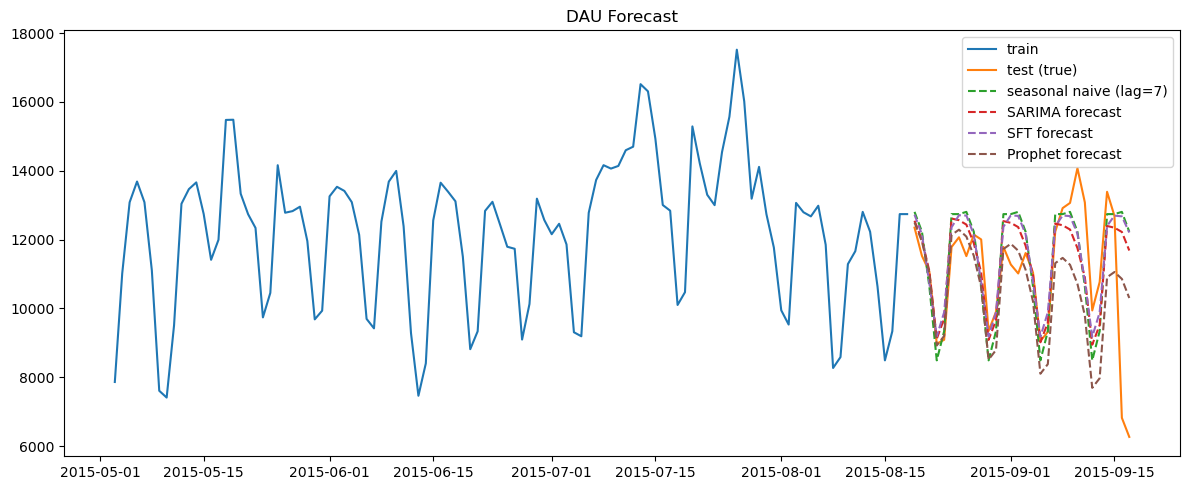

SFT MAE : 1025
SFT MAPE: 0.1144883299867741
SNA MAE : 1156
SNA MAPE: 0.12718161722628868
SARIMA MAE : 990
SARIMA MAPE: 0.10855862294937216
PROPHET MAE : 1281
PROPHET MAPE: 0.12751496951363664


In [111]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train.values, label="train")
plt.plot(test.index, test.values, label="test (true)")
plt.plot(test.index, pred_snaive.values, "--", label="seasonal naive (lag=7)")
plt.plot(test.index, pred_sarima.values, "--", label="SARIMA forecast")
plt.plot(test.index, pred_sft.values, "--", label="SFT forecast")
plt.plot(test.index, pred_prophet.values, "--", label="Prophet forecast")
plt.title("DAU Forecast")
plt.legend()
plt.tight_layout()
plt.show()

print("SFT MAE :", MAE(test, pred_sft))
print("SFT MAPE:", MAPE(test, pred_sft))

print("SNA MAE :", MAE(test, pred_snaive))
print("SNA MAPE:", MAPE(test, pred_snaive))

print("SARIMA MAE :", MAE(test, pred_sarima))
print("SARIMA MAPE:", MAPE(test, pred_sarima))

print("PROPHET MAE :", MAE(test, pred_prophet))
print("PROPHET MAPE:", MAPE(test, pred_prophet))